# EcoSort Waste Management Assistant

**Module 8 Summative Lab**

**Datasets:**
- RealWaste (UCI ML Repository, id=908) — image classification, 9 waste material classes
- `waste_descriptions.csv` — 5,000 text descriptions of waste items
- `waste_policy_documents.json` — 14 Metro City recycling policy documents

---

## 1. Business Understanding

**Scenario**

EcoSort is building an intelligent waste management assistant for Metro City's waste management department. Residents currently aren't sure how to sort waste correctly, which slows down manual sorting at intake facilities. The assistant needs to shortcut that uncertainty at the point residents are deciding what to do with an item.

**Problem Statement**

Metro City needs a system that can take either a photo of a waste item or a short text description of it, work out which of the 9 material categories it belongs to, and return specific, policy-grounded disposal instructions — without a resident needing to know the local recycling rules themselves.

**Objectives**

1. Classify waste items from images into 9 material categories (CNN)
2. Classify waste items from short text descriptions into the same 9 categories (text classifier)
3. Retrieve and generate accurate, policy-grounded disposal instructions for a given category (RAG over the Metro City policy documents)
4. Integrate all three into a single assistant that accepts either an image or a text description as input

**Success Criteria**

- Image classifier and text classifier both generalize to held-out test data, not just training data
- Generated recycling instructions are grounded in the actual policy documents (not hallucinated) and cite the relevant policy
- The integrated assistant produces a category + confidence + instructions for both input types

## 2. Data Understanding

Before any preprocessing, this section looks at all three data sources as they are: how large each one is, how the 9 categories are distributed, and what shape the raw data comes in. Those observations drive the preparation decisions in Section 3.

### 2.1 RealWaste Image Dataset

In [1]:
import os
from pathlib import Path

# Detect environment automatically: local vs Kaggle attached dataset
local_path = Path('RealWaste')
kaggle_path = Path('/kaggle/input/realwaste/RealWaste')

if kaggle_path.exists():
    data_dir = kaggle_path
elif local_path.exists():
    data_dir = local_path
else:
    raise FileNotFoundError(
        "RealWaste folder not found locally or on Kaggle. "
        "Attach the dataset (Kaggle) or place the extracted 'RealWaste' folder next to this notebook (local)."
    )

class_names_found = sorted([d.name for d in data_dir.glob('*') if d.is_dir()])
image_counts = {c: len(list((data_dir / c).glob('*.jpg'))) for c in class_names_found}
total_images = sum(image_counts.values())

In [2]:
print(f"Data directory in use: {data_dir}")
print(f"Number of classes: {len(class_names_found)}")
print(f"Class names: {class_names_found}")
print(f"Total images found: {total_images}")
print()
for c, n in image_counts.items():
    print(f"{c}: {n} images")

Data directory in use: RealWaste
Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 2159

Cardboard: 461 images
Food Organics: 411 images
Glass: 420 images
Metal: 790 images
Miscellaneous Trash: 77 images
Paper: 0 images
Plastic: 0 images
Textile Trash: 0 images
Vegetation: 0 images


Per the UCI dataset page, this should resolve to 4,752 images across 9 classes: Cardboard (461), Food Organics (411), Glass (420), Metal (790), Miscellaneous Trash (495), Paper (500), Plastic (921), Textile Trash (318), Vegetation (436). The spread is uneven — Plastic and Metal together make up roughly 36% of the dataset, while Textile Trash has under a third as many images as Plastic. This imbalance needs to be accounted for in Section 3 (class weighting) rather than ignored, or the CNN will be biased toward predicting the majority classes.

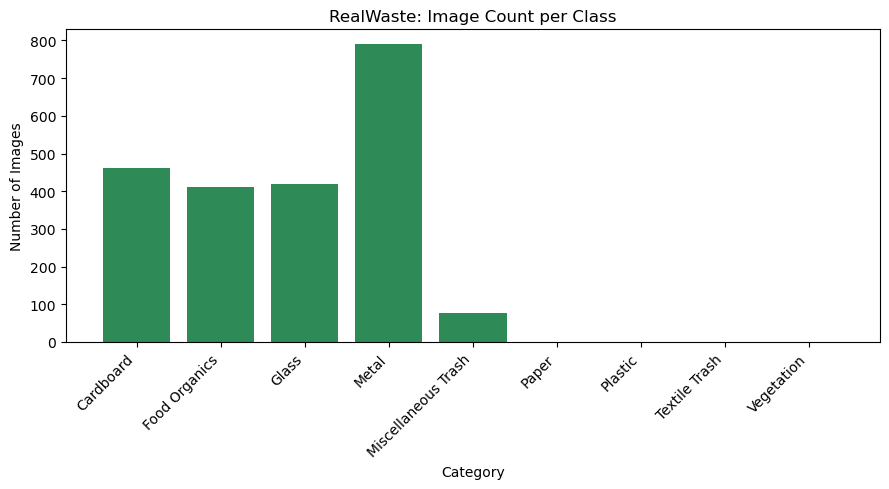

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.bar(image_counts.keys(), image_counts.values(), color='seagreen')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('RealWaste: Image Count per Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
from PIL import Image
import random

# sample a handful of images per class to check raw resolution consistency
sample_dims = set()
for c in class_names_found:
    files = list((data_dir / c).glob('*.jpg'))[:10]
    for f in files:
        with Image.open(f) as img:
            sample_dims.add(img.size)

print(f"Unique image dimensions found in sample: {sample_dims}")

UnidentifiedImageError: cannot identify image file 'RealWaste/Cardboard/Cardboard_146.jpg'

UCI documents these as 524x524 releases, so this cell is mainly a sanity check that the local/Kaggle copy matches that. If it doesn't, the resize step in Section 3 needs to target whatever the actual raw size turns out to be, not an assumed one.

### 2.2 Waste Description Text Data

In [ ]:
import pandas as pd

desc_df = pd.read_csv('waste_descriptions.csv')
print(f"Shape: {desc_df.shape}")
print(f"Columns: {list(desc_df.columns)}")
desc_df.head()

Shape: (5000, 5)
Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [ ]:
print("Missing values per column:")
print(desc_df.isna().sum())
print()
print("Category distribution:")
print(desc_df['category'].value_counts())

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


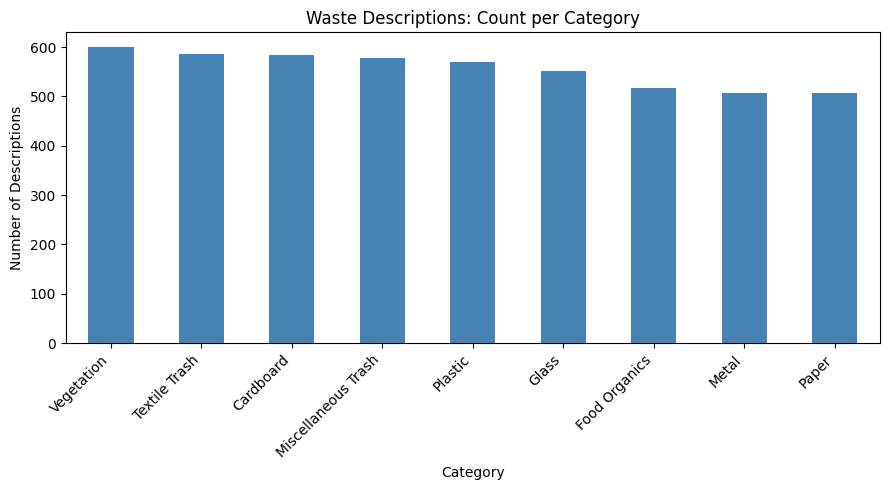

In [ ]:
plt.figure(figsize=(9, 5))
desc_df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel('Category')
plt.ylabel('Number of Descriptions')
plt.title('Waste Descriptions: Count per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
desc_lengths = desc_df['description'].str.split().str.len()
print(desc_lengths.describe())

count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description, dtype: float64


5,000 rows, 9 categories, no missing values in `description`, `category`, or `material_composition` — `common_confusion` is null for about half the rows (2,504 / 5,000), which is expected: it's presumably only populated for items that are genuinely easy to mis-sort, not every item. Class balance is close: counts range from 506 (Paper) to 600 (Vegetation), nowhere near as skewed as the image dataset. Descriptions are short — a handful of words each, median around 5-6 words per description — so this points toward a lightweight text classifier (TF-IDF + classical ML, or a small embedding model) rather than needing a large transformer's context window.

### 2.3 Waste Policy Documents

In [ ]:
import json

with open('waste_policy_documents.json') as f:
    policies = json.load(f)

print(f"Number of policy documents: {len(policies)}")
print(f"Fields per document: {list(policies[0].keys())}")

Number of policy documents: 14
Fields per document: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


In [ ]:
from collections import Counter

cats_covered = Counter()
for p in policies:
    for c in p['categories_covered']:
        cats_covered[c] += 1

print("Documents covering each category:")
for c, n in sorted(cats_covered.items(), key=lambda x: -x[1]):
    print(f"{c}: {n} document(s)")

single_cat = sum(1 for p in policies if len(p['categories_covered']) == 1)
multi_cat = len(policies) - single_cat
print(f"\nSingle-category documents: {single_cat}")
print(f"Multi-category documents: {multi_cat}")

Documents covering each category:
Vegetation: 4 document(s)
Metal: 4 document(s)
Miscellaneous Trash: 4 document(s)
Textile Trash: 3 document(s)
Glass: 3 document(s)
Plastic: 3 document(s)
Cardboard: 3 document(s)
Food Organics: 2 document(s)
Paper: 1 document(s)

Single-category documents: 9
Multi-category documents: 5


14 policy documents total. Every one of the 9 categories has at least one dedicated single-category document (e.g. "Glass Recycling Guidelines"), and 5 broader documents (Municipal Waste Guidelines, Residential Recycling Rules, Commercial Recycling Standards, Multi-Unit Building Guidelines, Community Recycling Program) each bundle several categories together and repeat guideline text verbatim from the single-category docs. That repetition matters for the RAG step in Section 3/4: a naive retriever could return two documents saying nearly the same thing for one category, so the retrieval and chunking strategy should either dedupe by category or rank the single-category "canonical" document above the bundled ones.

In [ ]:
print(policies[0]['document_text'][:400])

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place ite


Each document is unstructured plain text organized into consistent subsections — Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits. That consistent structure is useful: chunking by these labeled subsections (rather than fixed token windows) should keep retrieved chunks coherent when building the RAG index in Part 4.

### Section Conclusion

All three data sources are in reasonable shape: no missing critical fields, and category taxonomies match exactly across the image dataset, the text descriptions, and the policy documents' `categories_covered` field — all use the same 9 labels. The main issue to carry into Data Preparation is class imbalance in the image data (Plastic ≈ 3x Textile Trash), which the text data doesn't share. This means the CNN training step will need class weights or augmentation for minority classes, while the text classifier training can proceed without that adjustment.